# Cumulative quantitative experiment plots

This notebook reads the newest run directory from `Results/Quantitative_experiment`, loads its `summary.csv`, computes cumulative selected mining time for each algorithm, and creates cumulative mining-time-by-checkpoint plots for every `(event_type_count, online_theta)` pair.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from pandas.errors import EmptyDataError

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "Notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_ROOT = PROJECT_ROOT / "Results" / "Quantitative_experiment"
run_dirs = sorted(path for path in RESULTS_ROOT.iterdir() if path.is_dir() and path.name.startswith("run_"))
if not run_dirs:
    raise FileNotFoundError(f"No run_* directories found in {RESULTS_ROOT}")

RUN_DIR = run_dirs[-1]
SUMMARY_PATH = RUN_DIR / "summary.csv"
if not SUMMARY_PATH.exists():
    raise FileNotFoundError(f"summary.csv not found in newest run directory: {RUN_DIR}")

RUN_DIR

PosixPath('/Users/piotr/Praca/Nauka/publikacje/SNNs_ST_Patterns/Experiments_software/Results/Quantitative_experiment/run_20260521_144433')

In [2]:
summary = pd.read_csv(SUMMARY_PATH)
required_columns = {
    "event_type_count",
    "online_theta",
    "algorithm",
    "event_count",
    "mining_seconds",
}
missing_columns = required_columns.difference(summary.columns)
if missing_columns:
    raise ValueError(f"summary.csv is missing required columns: {sorted(missing_columns)}")

summary = summary.sort_values(
    ["event_type_count", "online_theta", "algorithm", "event_count"],
    ignore_index=True,
)

summary["cumulative_selected_mining_seconds"] = (
    summary
    .groupby(["event_type_count", "online_theta", "algorithm"])["mining_seconds"]
    .cumsum()
)

summary.head()

,event_type_count,online_theta,algorithm,event_count,target_pattern_count,pattern_count,within_tolerance,mining_seconds,cumulative_seconds,snapshot_extraction_seconds,...,metadata_path,absolute_pattern_count_difference,relative_pattern_count_difference,tolerance_patterns,spatial_radius,temporal_window,threshold,attempt_count,attempts_path,cumulative_selected_mining_seconds
0,15,0.1,online_stsp,500,28,28,True,2.228083,2.228083,0.000262,...,Results/Quantitative_experiment/run_20260521_1...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.228083
1,15,0.1,online_stsp,1000,4628,4628,True,2.011337,4.239419,0.115921,...,Results/Quantitative_experiment/run_20260521_1...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.239419
2,15,0.1,online_stsp,1500,1449,1449,True,2.112628,6.352048,0.017591,...,Results/Quantitative_experiment/run_20260521_1...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.352048
3,15,0.1,online_stsp,2000,3015,3015,True,2.531336,8.883384,0.034143,...,Results/Quantitative_experiment/run_20260521_1...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.883384
4,15,0.1,online_stsp,2500,16,16,True,2.211926,11.095310,0.000811,...,Results/Quantitative_experiment/run_20260521_1...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.095310


## Cumulative mining time grid

This cell creates one 3x3 matplotlib figure with cumulative mining-time plots for all `(event_type_count, online_theta)` pairs.


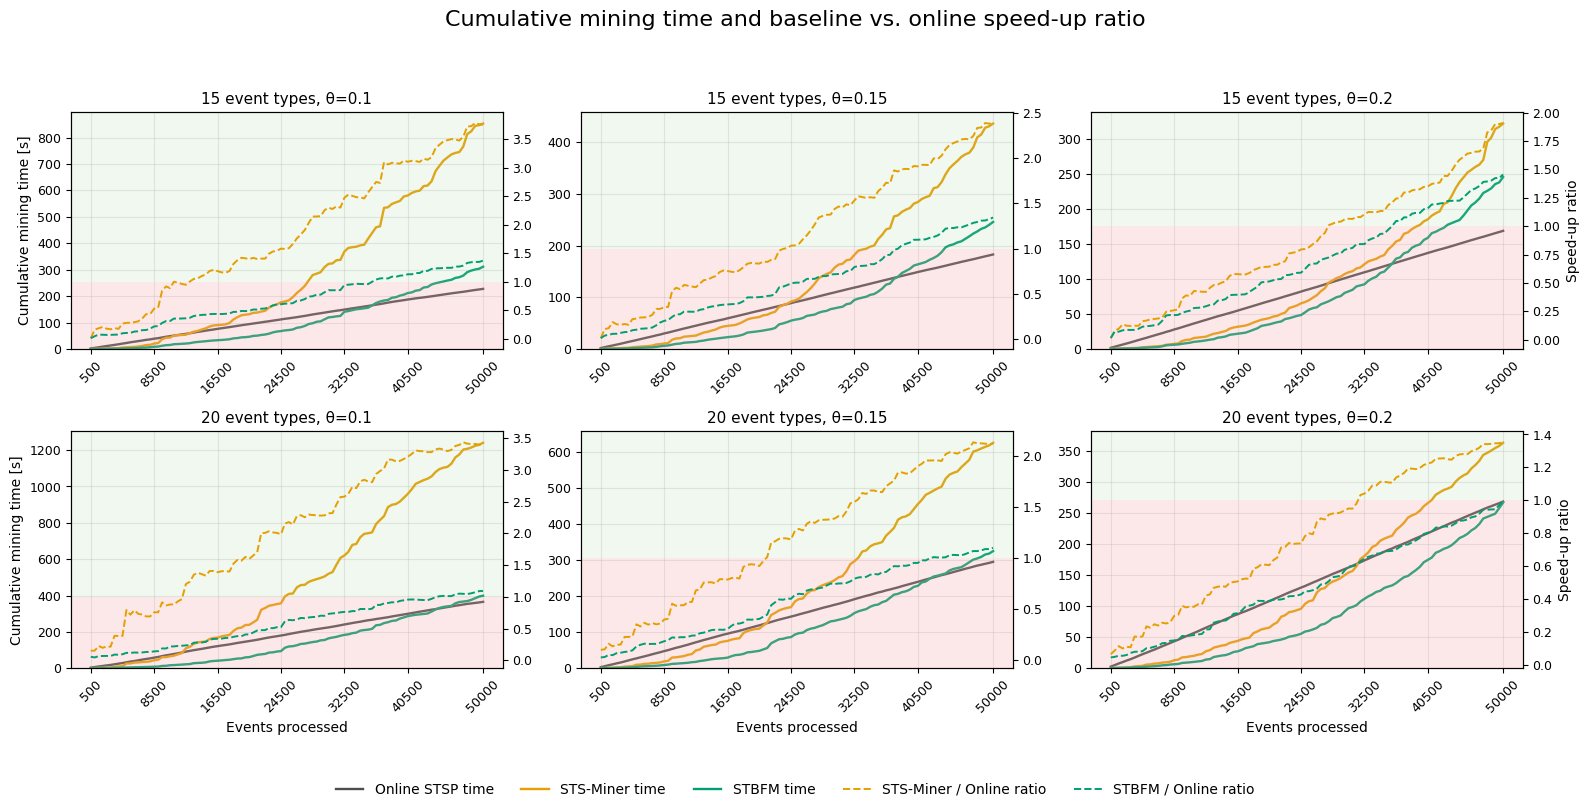

PosixPath('/Users/piotr/Praca/Nauka/publikacje/SNNs_ST_Patterns/Experiments_software/Results/Quantitative_experiment/run_20260521_144433/plots_cumulative/cumulative_mining_time_grid.png')

In [7]:
plot_dir = RUN_DIR / "plots_cumulative"
plot_dir.mkdir(parents=True, exist_ok=True)

algorithm_labels = {
    "online_stsp": "Online STSP",
    "sts_miner": "STS-Miner",
    "stbfm": "STBFM",
}
algorithm_colors = {
    "online_stsp": "#4D4D4D",
    "sts_miner": "#E69F00",
    "stbfm": "#009E73",
}
algorithm_order = ["online_stsp", "sts_miner", "stbfm"]
baseline_order = ["sts_miner", "stbfm"]
event_type_counts = [event_type_count for event_type_count in (15, 20) if event_type_count in set(summary["event_type_count"].dropna())]
online_thetas = sorted(summary["online_theta"].dropna().unique())
MAX_X_TICKS = 6

fig, axes = plt.subplots(
    nrows=len(event_type_counts),
    ncols=len(online_thetas),
    figsize=(16, 8),
    sharex=False,
    sharey=False,
)
if len(event_type_counts) == 1 and len(online_thetas) == 1:
    axes = [[axes]]
elif len(event_type_counts) == 1:
    axes = [axes]
elif len(online_thetas) == 1:
    axes = [[ax] for ax in axes]

legend_handles = []
legend_labels = []
for row_index, event_type_count in enumerate(event_type_counts):
    for col_index, online_theta in enumerate(online_thetas):
        ax = axes[row_index][col_index]
        ax_speedup = ax.twinx()
        subset = summary[
            (summary["event_type_count"] == event_type_count)
            & (summary["online_theta"].round(10) == round(float(online_theta), 10))
        ].copy()
        if subset.empty:
            ax.set_visible(False)
            ax_speedup.set_visible(False)
            print(f"No rows for event_type_count={event_type_count}, online_theta={online_theta}")
            continue

        rows_by_algorithm = {
            algorithm: subset[subset["algorithm"] == algorithm].sort_values("event_count")
            for algorithm in algorithm_order
        }

        for algorithm in algorithm_order:
            algorithm_rows = rows_by_algorithm[algorithm]
            if algorithm_rows.empty:
                continue
            line, = ax.plot(
                algorithm_rows["event_count"],
                algorithm_rows["cumulative_selected_mining_seconds"],
                linewidth=1.7,
                color=algorithm_colors.get(algorithm),
                label=f"{algorithm_labels.get(algorithm, algorithm)} time",
            )
            if row_index == 0 and col_index == 0:
                legend_handles.append(line)
                legend_labels.append(line.get_label())

        online_rows = rows_by_algorithm["online_stsp"]
        if not online_rows.empty:
            online_times = online_rows[["event_count", "cumulative_selected_mining_seconds"]].rename(
                columns={"cumulative_selected_mining_seconds": "online_cumulative_seconds"}
            )
            for baseline_algorithm in baseline_order:
                baseline_rows = rows_by_algorithm[baseline_algorithm]
                if baseline_rows.empty:
                    continue
                speedup_rows = baseline_rows[["event_count", "cumulative_selected_mining_seconds"]].merge(
                    online_times,
                    on="event_count",
                    how="inner",
                )
                speedup_rows = speedup_rows[speedup_rows["online_cumulative_seconds"] > 0]
                if speedup_rows.empty:
                    continue
                speedup = speedup_rows["cumulative_selected_mining_seconds"] / speedup_rows["online_cumulative_seconds"]
                line, = ax_speedup.plot(
                    speedup_rows["event_count"],
                    speedup,
                    linewidth=1.4,
                    linestyle="--",
                    color=algorithm_colors[baseline_algorithm],
                    label=f"{algorithm_labels[baseline_algorithm]} / Online ratio",
                )
                if row_index == 0 and col_index == 0:
                    legend_handles.append(line)
                    legend_labels.append(line.get_label())

        ratio_ymin, ratio_ymax = ax_speedup.get_ylim()
        ax_speedup.axhspan(ratio_ymin, min(1, ratio_ymax), facecolor="#F4A6A6", alpha=0.25, zorder=0)
        if ratio_ymax > 1:
            ax_speedup.axhspan(max(1, ratio_ymin), ratio_ymax, facecolor="#A8D5A2", alpha=0.16, zorder=0)
        ax_speedup.set_ylim(ratio_ymin, ratio_ymax)

        event_counts = sorted(subset["event_count"].unique())
        tick_step = max(1, len(event_counts) // MAX_X_TICKS)
        tick_values = event_counts[::tick_step]
        if event_counts and tick_values[-1] != event_counts[-1]:
            if len(tick_values) >= 2 and event_counts[-1] - tick_values[-1] < tick_values[-1] - tick_values[-2]:
                tick_values.pop()
            tick_values.append(event_counts[-1])
        ax.set_xticks(tick_values)
        ax.tick_params(axis="x", labelrotation=45, labelsize=9)
        ax.tick_params(axis="y", labelsize=9)
        ax_speedup.tick_params(axis="y", labelsize=9)
        ax.set_ylim(bottom=0)
        ax.margins(y=0)

        ax.set_title(f"{int(event_type_count)} event types, θ={online_theta:g}", fontsize=11)
        if row_index == len(event_type_counts) - 1:
            ax.set_xlabel("Events processed", fontsize=10)
        else:
            ax.set_xlabel("")
        if col_index == 0:
            ax.set_ylabel("Cumulative mining time [s]", fontsize=10)
        else:
            ax.set_ylabel("")
        if col_index == len(online_thetas) - 1:
            ax_speedup.set_ylabel("Speed-up ratio", fontsize=10)
        else:
            ax_speedup.set_ylabel("")
        ax.grid(True, alpha=0.3)

fig.legend(legend_handles, legend_labels, loc="lower center", ncol=5, frameon=False, fontsize=10)
fig.suptitle("Cumulative mining time and baseline vs. online speed-up ratio", fontsize=16, y=0.995)
fig.tight_layout(rect=(0, 0.07, 1, 0.955))

output_path = plot_dir / "cumulative_mining_time_grid.png"
fig.savefig(output_path, dpi=150)
plt.show()

output_path


## Pattern-set Jaccard similarity

This section compares the set of discovered event-type sequences from Online STSP against STS-Miner and STBFM. Jaccard similarity is computed at each checkpoint and then averaged for each `(event_type_count, online_theta)` setup. Only event-type counts 15 and 20 are included.


In [4]:
def resolve_result_path(path_value: str | Path) -> Path:
    path = Path(path_value)
    if path.is_absolute():
        return path
    return PROJECT_ROOT / path


def pattern_sequence_set(patterns_path: str | Path) -> set[str]:
    path = resolve_result_path(patterns_path)
    if not path.exists() or path.stat().st_size == 0:
        return set()

    try:
        patterns = pd.read_csv(path)
    except EmptyDataError:
        return set()
    if patterns.empty:
        return set()
    if "event_type_sequence" in patterns.columns:
        sequence_column = "event_type_sequence"
    elif "sequence" in patterns.columns:
        sequence_column = "sequence"
    else:
        raise ValueError(f"No sequence column found in {path}")

    return {
        " -> ".join(part.strip() for part in str(sequence).split("->"))
        for sequence in patterns[sequence_column].dropna()
    }


def jaccard_similarity(left: set[str], right: set[str]) -> float:
    union = left | right
    if not union:
        return 1.0
    return len(left & right) / len(union)


In [5]:
JACCARD_EVENT_TYPE_COUNTS = (15, 20)
comparison_algorithms = ["sts_miner", "stbfm", "sts_miner_vs_stbfm"]
jaccard_rows = []

for (event_type_count, online_theta, event_count), checkpoint_rows in summary.groupby(
    ["event_type_count", "online_theta", "event_count"]
):
    if int(event_type_count) not in JACCARD_EVENT_TYPE_COUNTS:
        continue

    rows_by_algorithm = checkpoint_rows.set_index("algorithm")
    pattern_sets = {}
    for algorithm in ("online_stsp", "sts_miner", "stbfm"):
        if algorithm in rows_by_algorithm.index:
            pattern_sets[algorithm] = pattern_sequence_set(rows_by_algorithm.loc[algorithm, "patterns_path"])

    comparison_pairs = [
        ("sts_miner", "online_stsp", "sts_miner"),
        ("stbfm", "online_stsp", "stbfm"),
        ("sts_miner_vs_stbfm", "sts_miner", "stbfm"),
    ]
    for comparison_name, left_algorithm, right_algorithm in comparison_pairs:
        if left_algorithm not in pattern_sets or right_algorithm not in pattern_sets:
            continue
        left_patterns = pattern_sets[left_algorithm]
        right_patterns = pattern_sets[right_algorithm]
        jaccard_rows.append({
            "event_type_count": int(event_type_count),
            "online_theta": float(online_theta),
            "event_count": int(event_count),
            "baseline_algorithm": comparison_name,
            "left_algorithm": left_algorithm,
            "right_algorithm": right_algorithm,
            "left_pattern_sequences": len(left_patterns),
            "right_pattern_sequences": len(right_patterns),
            "intersection_size": len(left_patterns & right_patterns),
            "union_size": len(left_patterns | right_patterns),
            "jaccard_similarity": jaccard_similarity(left_patterns, right_patterns),
        })

jaccard_by_checkpoint = pd.DataFrame(jaccard_rows).sort_values(
    ["event_type_count", "online_theta", "baseline_algorithm", "event_count"],
    ignore_index=True,
)
jaccard_summary = jaccard_by_checkpoint.groupby(
    ["event_type_count", "online_theta", "baseline_algorithm"],
    as_index=False,
).agg(
    average_jaccard_similarity=("jaccard_similarity", "mean"),
    std_jaccard_similarity=("jaccard_similarity", "std"),
    checkpoints=("event_count", "count"),
)

similarity_dir = RUN_DIR / "plots_similarity"
similarity_dir.mkdir(parents=True, exist_ok=True)
jaccard_by_checkpoint.to_csv(similarity_dir / "jaccard_by_checkpoint.csv", index=False)
jaccard_summary["std_jaccard_similarity"] = jaccard_summary["std_jaccard_similarity"].fillna(0.0)
jaccard_summary.to_csv(similarity_dir / "jaccard_summary.csv", index=False)
jaccard_summary


,event_type_count,online_theta,baseline_algorithm,average_jaccard_similarity,std_jaccard_similarity,checkpoints
0,15,0.10,stbfm,0.074853,0.037082,100
1,15,0.10,sts_miner,0.047411,0.029888,100
2,15,0.10,sts_miner_vs_stbfm,0.378880,0.323089,100
3,15,0.15,stbfm,0.090684,0.043155,100
4,15,0.15,sts_miner,0.051935,0.036622,100
5,15,0.15,sts_miner_vs_stbfm,0.333819,0.288766,100
6,15,0.20,stbfm,0.112917,0.101742,100
7,15,0.20,sts_miner,0.070146,0.103824,100
8,15,0.20,sts_miner_vs_stbfm,0.360808,0.301115,100
9,20,0.10,stbfm,0.052293,0.028496,100


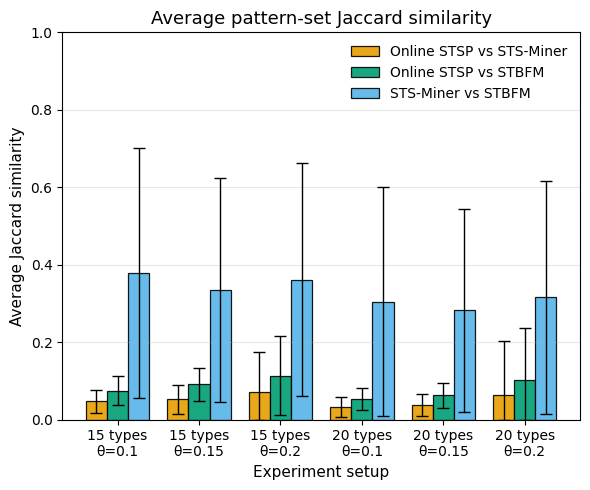

PosixPath('/Users/piotr/Praca/Nauka/publikacje/SNNs_ST_Patterns/Experiments_software/Results/Quantitative_experiment/run_20260521_144433/plots_similarity/average_jaccard_grouped.png')

In [6]:
baseline_titles = {
    "sts_miner": "Online STSP vs STS-Miner",
    "stbfm": "Online STSP vs STBFM",
    "sts_miner_vs_stbfm": "STS-Miner vs STBFM",
}
baseline_colors = {
    "sts_miner": "#E69F00",
    "stbfm": "#009E73",
    "sts_miner_vs_stbfm": "#56B4E9",
}
comparison_algorithms = ["sts_miner", "stbfm", "sts_miner_vs_stbfm"]

setup_keys = sorted(
    jaccard_summary[["event_type_count", "online_theta"]].drop_duplicates().itertuples(index=False, name=None)
)
setup_labels = [f"{int(event_type_count)} types\nθ={online_theta:g}" for event_type_count, online_theta in setup_keys]
x_positions = list(range(len(setup_keys)))
bar_width = 0.26
offsets = {
    "sts_miner": -bar_width,
    "stbfm": 0.0,
    "sts_miner_vs_stbfm": bar_width,
}

fig, ax = plt.subplots(figsize=(6, 5))
for comparison_algorithm in comparison_algorithms:
    means = []
    lower_errors = []
    upper_errors = []
    for event_type_count, online_theta in setup_keys:
        row = jaccard_summary[
            (jaccard_summary["event_type_count"] == event_type_count)
            & (jaccard_summary["online_theta"].round(10) == round(float(online_theta), 10))
            & (jaccard_summary["baseline_algorithm"] == comparison_algorithm)
        ]
        if row.empty:
            mean = 0.0
            std = 0.0
        else:
            mean = float(row["average_jaccard_similarity"].iloc[0])
            std = float(row["std_jaccard_similarity"].iloc[0])
        means.append(mean)
        lower_errors.append(min(std, mean))
        upper_errors.append(std)

    ax.bar(
        [position + offsets[comparison_algorithm] for position in x_positions],
        means,
        width=bar_width,
        yerr=[lower_errors, upper_errors],
        capsize=4,
        color=baseline_colors[comparison_algorithm],
        edgecolor="black",
        linewidth=0.9,
        alpha=0.9,
        label=baseline_titles[comparison_algorithm],
        error_kw={"elinewidth": 1.0, "capthick": 1.0, "ecolor": "black"},
    )

ax.set_title("Average pattern-set Jaccard similarity", fontsize=13)
ax.set_xlabel("Experiment setup", fontsize=11)
ax.set_ylabel("Average Jaccard similarity", fontsize=11)
ax.set_xticks(x_positions)
ax.set_xticklabels(setup_labels)
ax.set_ylim(0, 1)
ax.grid(True, axis="y", alpha=0.3)
ax.tick_params(axis="x", labelrotation=0, labelsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.legend(frameon=False, fontsize=10)
fig.tight_layout()

output_path = similarity_dir / "average_jaccard_grouped.png"
fig.savefig(output_path, dpi=150)
plt.show()

output_path
